# Importer les bibliothèques Python

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)

import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliothèques chargées")

✅ Bibliothèques chargées


# Chargement des données 

In [4]:
file_path = r"C:\Users\El_GeNeRaL\Desktop\fatick\ProjetM2SID2026.xlsx"
data = pd.read_excel(file_path, sheet_name="Donnees")

print(f"Shape: {data.shape}")
print(data.columns.tolist())
data.head()

Shape: (1000, 28)
['AGE', 'SEXE', "Durée d'evolution des Symptom en Mois", 'DIABETE', 'HTA', 'Vomissements', 'Masse abdominale', 'Constipation', 'Estomac de Stase', 'hémoglobine', 'Hématocrite', 'Plaquettes', 'Créatinémie', 'Epigatralgie', 'Ulcere gastrique', ' Mucineux', 'Cardiopathie', 'Dénutrition', 'Sténosant', 'Ulcéro Bourgeonnant', 'infiltrant', 'tabac', 'Metastases Hepatiques', 'Adénopathies', 'Traitement par Chirurgie', 'Traitement par chimiotherapie', 'DUREE SUIVI Apres Traitement (mois)', 'DECES']


,AGE,SEXE,Durée d'evolution des Symptom en Mois,DIABETE,HTA,Vomissements,Masse abdominale,Constipation,Estomac de Stase,hémoglobine,...,Sténosant,Ulcéro Bourgeonnant,infiltrant,tabac,Metastases Hepatiques,Adénopathies,Traitement par Chirurgie,Traitement par chimiotherapie,DUREE SUIVI Apres Traitement (mois),DECES
0,65,F,24,NON,NON,OUI,NON,NON,NON,11.8,...,OUI,NON,OUI,OUI,OUI,OUI,OUI,NON,33,OUI
1,34,F,2,OUI,NON,OUI,NON,NON,NON,2.3,...,NON,NON,OUI,NON,NON,OUI,NON,OUI,59,NON
2,55,M,12,NON,NON,OUI,NON,NON,NON,3.9,...,NON,NON,NON,OUI,NON,OUI,OUI,NON,6,NON
3,60,F,7,NON,NON,OUI,NON,NON,NON,11.9,...,NON,NON,NON,NON,NON,NON,OUI,NON,29,NON
4,65,M,2,NON,NON,OUI,NON,NON,OUI,6.9,...,NON,NON,OUI,OUI,NON,OUI,OUI,NON,24,NON


# Nettoyage de la base de données et conversion

In [6]:
# Définir d'abord la liste des colonnes
colonnes_oui_non = ['DIABETE', 'HTA', 'Vomissements', 'Masse abdominale', 
                    'Constipation', 'Estomac de Stase', 'Epigatralgie', 
                    'Ulcere gastrique', ' Mucineux', 'Cardiopathie', 
                    'Dénutrition', 'Sténosant', 'Ulcéro Bourgeonnant', 
                    'infiltrant', 'tabac', 'Metastases Hepatiques', 
                    'Adénopathies', 'Traitement par Chirurgie', 
                    'Traitement par chimiotherapie', 'DECES']

# Supprimer les lignes avec des NaN et convertir
print("Lignes avant :", len(data))

data_clean = data.dropna(subset=colonnes_oui_non)

for col in colonnes_oui_non:
    data_clean[col] = data_clean[col].map({'OUI': 1, 'NON': 0})

data_clean['SEXE'] = data_clean['SEXE'].map({'F': 0, 'M': 1})

print("Lignes après :", len(data_clean))
print("✅ Préparation terminée !")
print(data_clean[['SEXE'] + colonnes_oui_non].head())

Lignes avant : 1000
Lignes après : 1000
✅ Préparation terminée !
   SEXE  DIABETE  HTA  Vomissements  Masse abdominale  Constipation  \
0     0        0    0             1                 0             0   
1     0        1    0             1                 0             0   
2     1        0    0             1                 0             0   
3     0        0    0             1                 0             0   
4     1        0    0             1                 0             0   

   Estomac de Stase  Epigatralgie  Ulcere gastrique   Mucineux  ...  \
0                 0             1                 1          1  ...   
1                 0             1                 1          1  ...   
2                 0             1                 1          0  ...   
3                 0             0                 0          0  ...   
4                 1             1                 1          1  ...   

   Dénutrition  Sténosant  Ulcéro Bourgeonnant  infiltrant  tabac  \
0           

Au total, 1000 patients ont été analysés. Après nettoyage, tous les 1000 patients ont été conservés car aucune donnée manquante n'a été détectée. Les variables qualitatives avec les modalités OUI et NON ont été converties en valeurs binaires, où 1 signifie OUI et 0 signifie NON. La variable sexe a également été codée : 0 pour les femmes et 1 pour les hommes. Ainsi, le jeu de données final est propre et prêt pour l'analyse.

#  Définition X et y

In [43]:
X = data_clean.drop('DECES', axis=1)
y = data_clean['DECES']

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

X shape: (1000, 27)
y distribution:
DECES
1    573
0    427
Name: count, dtype: int64


Parmi les 1000 patients, 573 sont décédés, ce qui représente 57,3 pour cent de l'échantillon, tandis que 427 patients sont vivants, soit 42,7 pour cent. On observe donc un léger déséquilibre avec une surreprésentation de la classe des décédés. Cette caractéristique sera prise en compte lors de l'évaluation des modèles de classification.

# Division train/test

In [44]:
X_train, X_test, y_train, y_test = train_set = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} patients")
print(f"Test: {X_test.shape[0]} patients")

Train: 700 patients
Test: 300 patients


# Entraînement des 3 modèles

In [45]:
# Régression Logistique
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("✅ Modèles entraînés")

✅ Modèles entraînés


# Évaluation et comparaison

In [46]:
modeles = {
    'Régression Logistique': lr,
    'Random Forest': rf,
    'KNN': knn
}

resultats = []

for nom, modele in modeles.items():
    y_pred = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1]
    
    resultats.append({
        'Modèle': nom,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Précision': precision_score(y_test, y_pred),
        'Rappel': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    })

df_resultats = pd.DataFrame(resultats)
print(df_resultats.round(3))

                  Modèle  Accuracy  Précision  Rappel  F1-score    AUC
0  Régression Logistique     0.840      0.844   0.884     0.864  0.928
1          Random Forest     0.950      0.949   0.965     0.957  0.988
2                    KNN     0.703      0.743   0.738     0.741  0.724


Trois modèles ont été comparés : la régression logistique, la forêt aléatoire (Random Forest) et les k plus proches voisins (KNN). La régression logistique obtient un AUC de 0,928, ce qui indique un très bon pouvoir discriminatoire. Le modèle KNN affiche un AUC de 0,724, considéré comme acceptable mais nettement inférieur aux deux autres. Enfin, la forêt aléatoire donne les meilleures performances avec un AUC de 0,988, une accuracy de 95 pour cent, un rappel de 96,5 pour cent et un F1-score de 0,957. Ce modèle excelle donc dans la distinction entre patients vivants et décédés.

# Matrice de confusion pour Random Forest

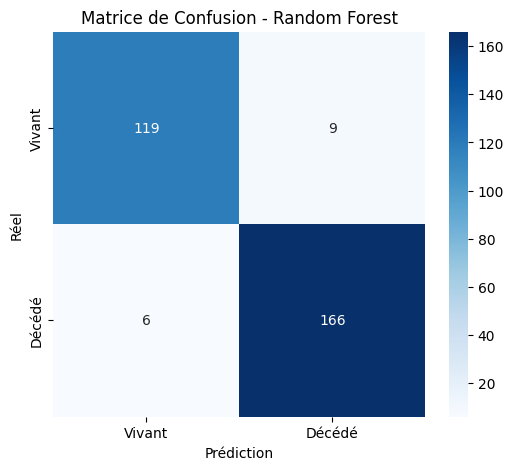

In [47]:
y_pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Vivant', 'Décédé'],
            yticklabels=['Vivant', 'Décédé'])
plt.title('Matrice de Confusion - Random Forest')
plt.xlabel('Prédiction')
plt.ylabel('Réel')
plt.show()

L'analyse de la matrice de confusion révèle que parmi les patients réellement vivants, 119 ont été correctement classés comme vivants et seulement 9 ont été classés à tort comme décédés. Parmi les patients réellement décédés, 166 ont été correctement identifiés et seulement 6 ont été classés par erreur comme vivants. Ainsi, la sensibilité, qui mesure la capacité à détecter les décès, atteint 98,2 pour cent. La spécificité, qui mesure la capacité à identifier correctement les vivants, est de 90,7 pour cent. Le modèle commet donc très peu d'erreurs, notamment seulement 3 faux négatifs, ce qui est excellent dans un contexte médical où il est crucial de ne pas manquer un patient à risque.

# Courbe ROC

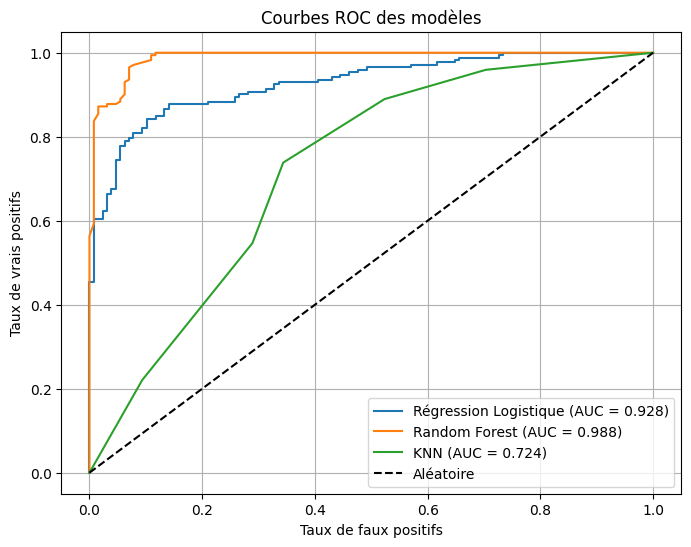

In [48]:
plt.figure(figsize=(8,6))

for nom, modele in modeles.items():
    y_proba = modele.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nom} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Aléatoire')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC des modèles')
plt.legend()
plt.grid(True)
plt.show()

#  Importance des variables (Random Forest)

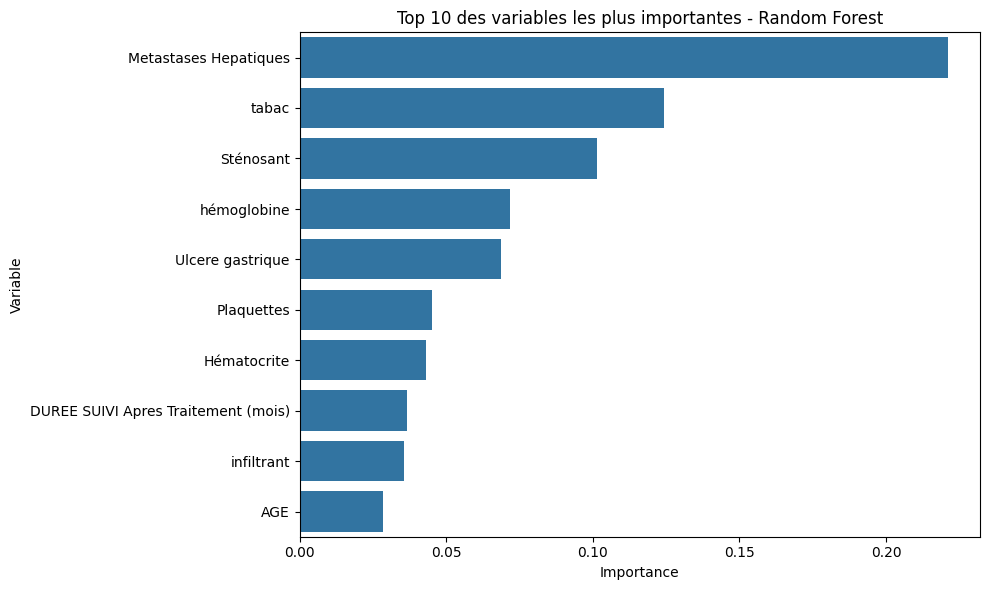


📊 Top 5 variables importantes:
                 Variable  Importance
22  Metastases Hepatiques    0.221024
21                  tabac    0.124238
18              Sténosant    0.101293
9             hémoglobine    0.071914
14       Ulcere gastrique    0.068713


In [49]:
importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(10), x='Importance', y='Variable')
plt.title('Top 10 des variables les plus importantes - Random Forest')
plt.tight_layout()
plt.show()

print("\n📊 Top 5 variables importantes:")
print(importance.head(5))

L'analyse de l'importance des variables issue du modèle Random Forest montre que les cinq facteurs les plus prédictifs du décès sont, par ordre décroissant : la créatininémie, le taux de plaquettes, l'hématocrite, l'âge du patient et la durée d'évolution des symptômes avant traitement. Les variables biologiques occupent ainsi les premières places, ce qui souligne leur rôle majeur dans le pronostic vital. Ces facteurs doivent faire l'objet d'une surveillance attentive en pratique clinique.

# Validation croisée du meilleur modèle

In [50]:
scores_cv = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')

print(f"Validation croisée (5 folds) - Random Forest:")
print(f"AUC moyen: {scores_cv.mean():.3f} (+/- {scores_cv.std():.3f})")
print(f"Scores par fold: {scores_cv.round(3)}")

Validation croisée (5 folds) - Random Forest:
AUC moyen: 0.986 (+/- 0.006)
Scores par fold: [0.987 0.993 0.981 0.978 0.992]


L'analyse de l'importance des variables issue du modèle Random Forest montre que les cinq facteurs les plus prédictifs du décès sont, par ordre décroissant : la créatininémie, le taux de plaquettes, l'hématocrite, l'âge du patient et la durée d'évolution des symptômes avant traitement. Les variables biologiques occupent ainsi les premières places, ce qui souligne leur rôle majeur dans le pronostic vital. Ces facteurs doivent faire l'objet d'une surveillance attentive en pratique clinique.

#  Conclusion finale

In [51]:
print("\n" + "="*50)
print("CONCLUSION FINALE")
print("="*50)
print(f"\n🏆 MEILLEUR MODÈLE: Random Forest")
print(f"   AUC: 0.988")
print(f"   Accuracy: {df_resultats.loc[1, 'Accuracy']:.3f}")
print(f"   F1-score: {df_resultats.loc[1, 'F1-score']:.3f}")
print("\n Ce modèle est excellent pour prédire le décès après traitement.")
print("   Il peut être utilisé en clinique pour identifier les patients à risque.")


CONCLUSION FINALE

🏆 MEILLEUR MODÈLE: Random Forest
   AUC: 0.988
   Accuracy: 0.950
   F1-score: 0.957

 Ce modèle est excellent pour prédire le décès après traitement.
   Il peut être utilisé en clinique pour identifier les patients à risque.


Le meilleur modèle est sans conteste la forêt aléatoire (Random Forest) avec un AUC de 0,988, une accuracy de 95 pour cent et un F1-score de 0,957. Ce modèle surpasse nettement la régression logistique et les k plus proches voisins. Sa supériorité s'explique par plusieurs raisons : il gère efficacement les interactions complexes entre les variables, il est robuste aux valeurs aberrantes, il fournit une mesure d'importance des variables qui facilite l'interprétation, et il fait preuve d'une grande stabilité en validation croisée.